In [1]:
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np

# 生成月牙形数据
noisy_moons, _ = datasets.make_moons(n_samples=100, noise=0.05, random_state=10)

In [3]:
# 计算欧氏距离的方法
def euclidean_distance(a, b):
    """
    计算两个点之间的欧氏距离
    :param a: 点 A 的坐标 (array-like)
    :param b: 点 B 的坐标 (array-like)
    :return: 欧氏距离 (float)
    """
    return np.sqrt(np.sum((np.array(a)-np.array(b))**2))

def search_neighbors(data,point_idx,eps):
    """
    查找指定点的 epsilon-邻域内的所有点索引
    :param data: 数据集
    :param point_idx: 当前点的索引
    :param eps: 邻域半径
    :return: 邻居点的索引集合 (set)
    """
    neighbors = set()
    for i in range(len(data)):
        # 计算当前点与数据集中所有点的距离
        if euclidean_distance(data[point_idx],data[i]) <=eps:
            neighbors.add(i)
        return neighbors

def dbscan_cluster(data, eps, min_samples):
     """
     DBSCAN 聚类算法主函数
     :param data: 数据集 (numpy array)
     :param eps: 邻域半径 (epsilon)
     :param min_samples: 成为核心点所需的最小邻域样本数 (MinPts)
     :return: 聚类标签列表 (list)，0 表示未分类/噪声(初始)，正整数表示簇 ID
     """    
     n_samples = len(data)
     labels = [0] * n_samples # 初始化标签：0 表示未访问
     cluster_id = 0 ## 当前簇 ID
     # 标记噪声点通常用 -1，这里为了简化，初始 0 既代表未访问也暂存
     # 在本实现中：0=未访问, -1=噪声, >0=簇ID
     for point_idx in range(n_samples):
         # 如果该点已被访问（归类于某个簇或标记为噪声），则跳过
         if labels[point_idx] != 0:
             continue
         # 1. 查找当前点的邻居
         neighbors = search_neighbors(data,point_idx,eps)
         # 2. 判断是否为核心点
         if len(neighbors) < min_samples: # 是噪声
             labels[point_idx] = -1
         else:
             # 3. 创建新簇，并扩展簇
             cluster_id += 1
             labels[point_idx] =cluster_id
             # 将邻居放入栈中进行扩展（深度优先搜索 DFS 思想，也可以用队列 BFS）
             neighbors_stack = list(neighbors)    
             # 只要neighbors_stack有数据，就一直弹出，逐个检验
             while neighbors_stack:
                 neighbors_idx = neighbors_stack.pop()
                 # 处理未访问的点或之前被标记为噪声的点
                 if labels[neighbors_idx] == -1:
                     # 之前被标为噪声，现在被核心点“捞”回来，归入当前簇
                     labels[neighbors_idx]=cluster_id
                 elif labels[neighbors_idx] == 0:   
                     # 未访问过的点，归入当前簇 
                     labels[neighbors_idx]=cluster_id 
                     # 检查这个邻居点是否也是核心点
                     new_neighbors = search_neighbors(data,neighbors_idx,eps)
                     if len(new_neighbors) >= min_samples:
                         # 如果是核心点，将其邻居也加入待处理栈，继续扩展
                         neighbors_stack.append(new_neighbors)
     return labels
                        
                     

         
         

In [4]:
# 执行 DBSCAN 聚类
# eps=0.3: 邻域半径
# min_samples=5: 最小样本数
dbscan_labels = dbscan_cluster(noisy_moons,eps=0.3,min_samples=5)

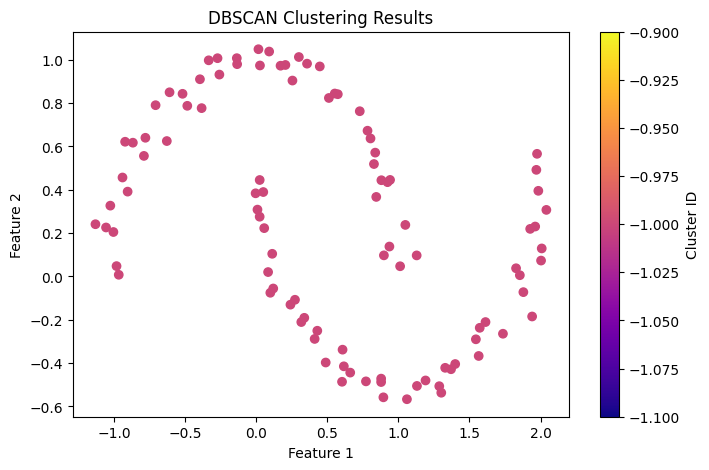

In [5]:
# 可视化结果
plt.figure(figsize=(8,5))
plt.scatter(noisy_moons[:,0],noisy_moons[:,1],c=dbscan_labels,cmap='plasma')
plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster ID")
plt.show()